In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jainilcoder/online-payment-fraud-detection/onlinefraud.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/jainilcoder/online-payment-fraud-detection/onlinefraud.csv")

# EDA

## Exploring common information around the dataset

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.shape

(6362620, 11)

In [6]:
print(df.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%      0.000000e+00    0.000000e+00

In [7]:
print(df.describe(include="object"))

            type     nameOrig     nameDest
count    6362620      6362620      6362620
unique         5      6353307      2722362
top     CASH_OUT  C1530544995  C1286084959
freq     2237500            3          113


In [8]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


Since no null values and duplicated rows to handle, time to explore the dataset and find any patterns, information and anamolies.

## Sub - parts of EDA

### Inspecting the `isFraud` - target column to notice the distribution

In [10]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

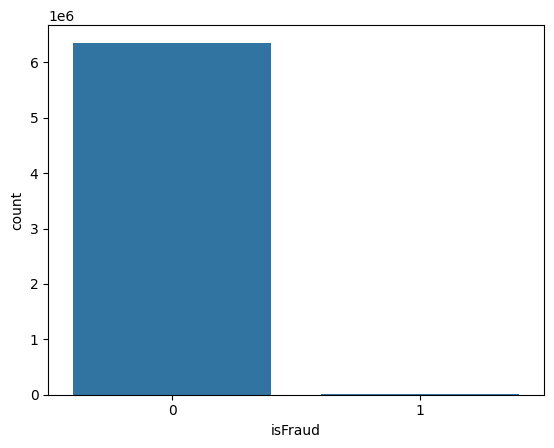

In [12]:
sns.countplot(data=df, x="isFraud")
plt.show()

> **Observation:**  
> The dataset is **highly imbalanced**, with only **0.12%** of the transactions being fraudulent. This reflects real-world financial systems, where fraudulent transactions are naturally rare. Therefore, the imbalance itself is not a problem with the dataset and should not be artificially removed before analysis.
>
> However, this imbalance must be considered during model training, as many machine learning algorithms tend to favor the majority class. To improve the model's ability to detect fraudulent transactions, techniques such as **class weighting**, **oversampling (e.g., SMOTE)**, or **undersampling** can be used during training.

### Random observation while inspecting the columns

In [13]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4937286,350,CASH_OUT,14669.53,C1679182661,0.00,0.00,C2002660643,315599.00,330268.53,0,0
1258870,134,CASH_OUT,226039.92,C1758499594,11765.00,0.00,C1449026737,625840.81,851880.74,0,0
215620,13,CASH_OUT,395545.88,C322090465,10939.00,0.00,C146348361,545626.08,815652.01,0,0
5930556,404,CASH_OUT,150195.97,C1454365671,0.00,0.00,C231765415,12868077.49,12477587.98,0,0
4192205,305,CASH_IN,40382.94,C1831773792,3989855.89,4030238.83,C502484712,3396505.95,3356123.01,0,0


> **Observation: Balance Fields**
>
> While exploring the dataset, I noticed that the balance values do not always satisfy the expected transaction equations:
>
> - `newbalanceOrig ≈ oldbalanceOrg - amount`
> - `newbalanceDest ≈ oldbalanceDest + amount`
>
> Several transactions contain balance values that appear inconsistent, such as destination balances remaining `0` even after receiving funds or sender balances becoming `0` when the transaction amount exceeds the available balance.
>
> **Learning:**
>
> This is a known characteristic of the PaySim dataset. The simulator does not always maintain perfectly consistent balance information for every transaction, particularly for merchant accounts or accounts with unavailable balance data. Therefore, these inconsistencies are part of the dataset rather than data entry errors and should not be corrected during EDA. They may even provide useful signals for fraud detection during feature engineering.

### In the remaining columns, let's inspect `type` - Transaction Types

In [14]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

| Type         | Meaning                                                    | Example                                                       |
| ------------ | ---------------------------------------------------------- | ------------------------------------------------------------- |
| **CASH_IN**  | Depositing cash into an account                            | You visit an ATM/bank and deposit ₹5,000 into your account.   |
| **CASH_OUT** | Withdrawing cash from an account                           | You withdraw ₹5,000 from an ATM.                              |
| **PAYMENT**  | Paying a merchant for goods/services                       | You pay ₹800 to Amazon or Swiggy.                             |
| **TRANSFER** | Sending money from one account to another                  | You send ₹2,000 to your friend's bank account using UPI/NEFT. |
| **DEBIT**    | Money deducted from your account for a banking transaction | EMI deduction, bank charges, automatic bill payment, etc.     |


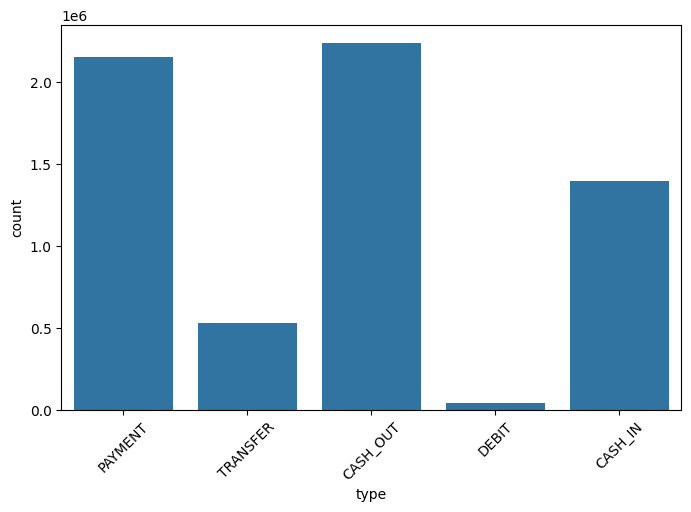

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="type")

plt.xticks(rotation=45)

plt.show()

> **Observation**
>
>The above plot shows the distribution of different transaction types across the dataset. While it tells us how frequently each transaction type occurs, it does not indicate how these transactions are distributed between fraudulent and legitimate cases.
>
>To better understand the relationship between transaction type and fraud, we need to examine how many transactions of each type are classified as **fraud (`isFraud = 1`)** and **non-fraud (`isFraud = 0`)**. This provides a clearer picture of which transaction types are more susceptible to fraudulent activity.
> 
>A convenient way to analyze this relationship is by using:
> 
>```python
>pd.crosstab(df["type"], df["isFraud"])
>```
>
>`pd.crosstab()` creates a contingency table that shows the frequency of each combination of transaction type and fraud status.

In [16]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [17]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


Fraudulent transactions in this dataset occur almost exclusively during TRANSFER and CASH_OUT operations. 

This is intuitive, as fraudsters typically transfer stolen funds to another account before withdrawing them as cash, whereas transaction types such as PAYMENT, CASH_IN, and DEBIT are not represented as fraudulent in this simulated dataset.

### Amount Distribution

In [18]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

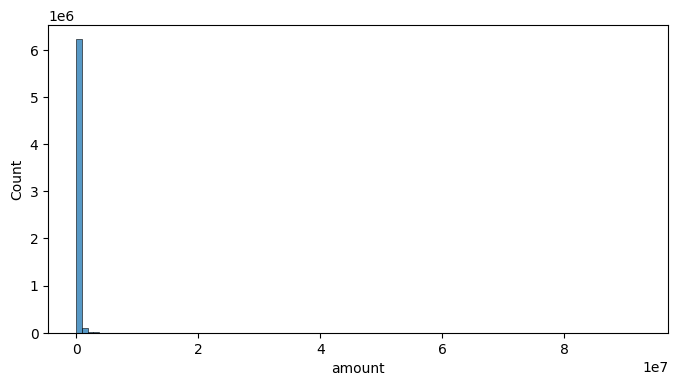

In [19]:
plt.figure(figsize=(8,4))

sns.histplot(df["amount"], bins=100)

plt.show()

<Axes: xlabel='amount'>

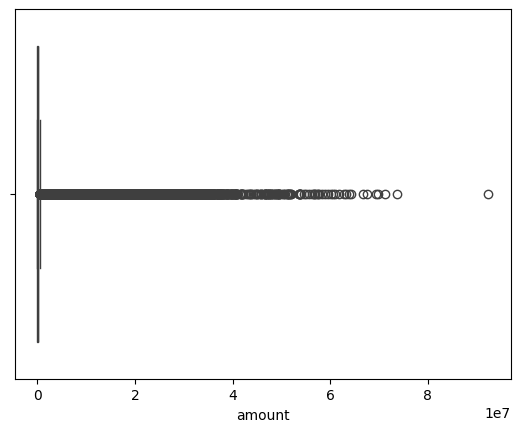

In [20]:
sns.boxplot(x=df["amount"])

> **Observation**
>
>The transaction amounts are **highly right-skewed**, which means most transactions involve smaller amounts, while only a few involve very large amounts.
>
>The boxplot also shows several high-value transactions that appear as outliers. However, since this is a financial dataset, these large transactions are not necessarily errors. They could be genuine transactions, so they should be examined further instead of being removed based only on their high values.

### Fraud vs Amount 

<Axes: xlabel='isFraud', ylabel='amount'>

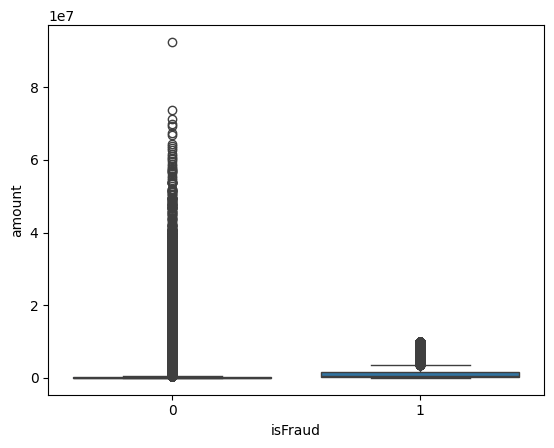

In [21]:
sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

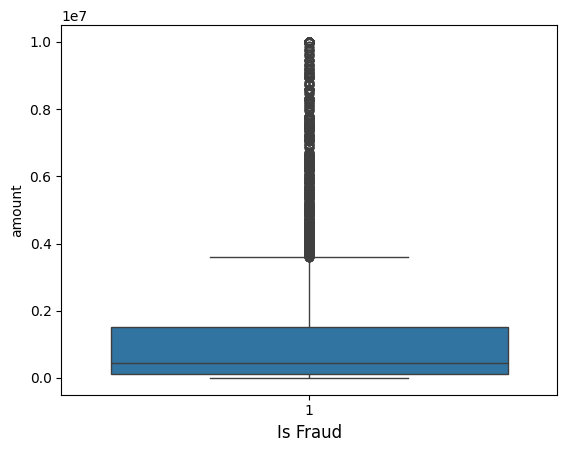

In [22]:
isFraud_df = df[df["isFraud"]==1]
ax = sns.boxplot(
    data=isFraud_df,
    x="isFraud",
    y="amount"
)
ax.set_xlabel("Is Fraud", fontsize=12)
plt.show()

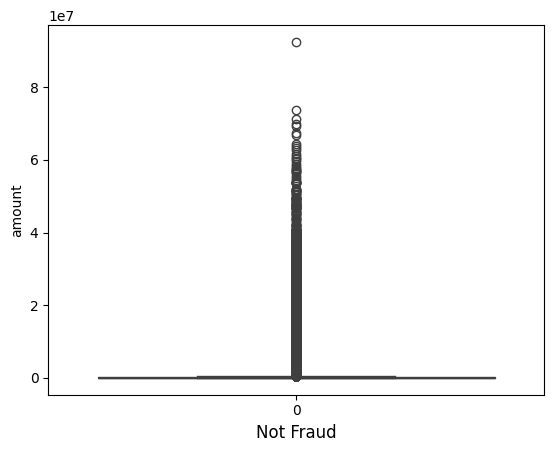

In [23]:
isNonFraud_df = df[df["isFraud"]==0]
ax = sns.boxplot(
    data=isNonFraud_df,
    x="isFraud",
    y="amount"
)
ax.set_xlabel("Not Fraud", fontsize=12)
plt.show()

> **Observation**
>
>Both fraudulent and non-fraudulent transactions contain high-value outliers.
>
>Since large financial transactions can be legitimate, these observations should not be treated as errors or removed solely based on their amount.
>
>The overlap between the two distributions suggests that **transaction amount alone is not sufficient to distinguish fraudulent transactions**.
>
>By overlap, we mean that both fraudulent and non-fraudulent transactions span a wide range of amounts, from small to large values. Therefore, a transaction cannot be classified as fraudulent based solely on its amount. Additional features will likely be required to accurately identify fraudulent behavior.

### Time Analysis

<Axes: xlabel='step', ylabel='Count'>

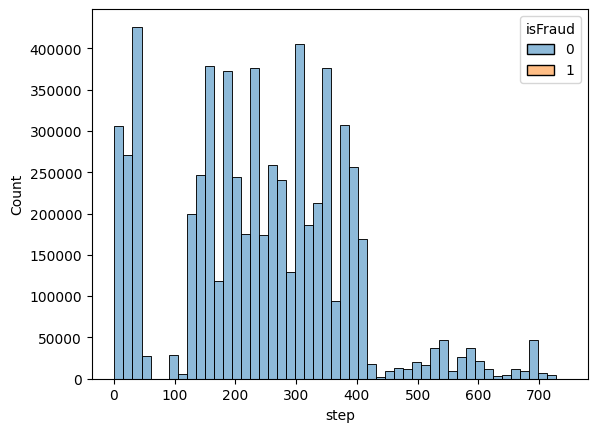

In [24]:
sns.histplot(
    data=df,
    x="step",
    hue="isFraud",
    bins=50
)

> Let's break down the visualization, as it seems to be overlapping and that the fraud count is being hidden behind the non fraud counts
>
> Since only 0.12% of the data is fraud, the fraud bars are tiny compared to the non-fraud bars, so they get squeezed/accumulated in the blue bars in 0-500 count on Y - axis.

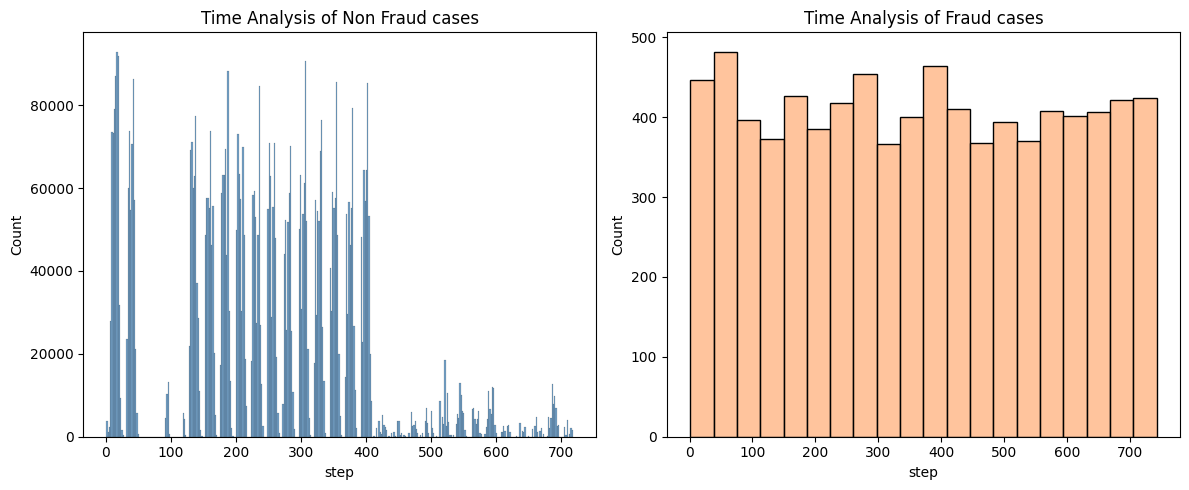

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.histplot(
    data=isNonFraud_df,
    x="step",
    color="steelblue",
    ax = axes[0]
)
axes[0].set_title("Time Analysis of Non Fraud cases")

sns.histplot(
    data=isFraud_df,
    x="step",
    color=sns.xkcd_rgb['peach'],
    ax = axes[1]
)
axes[1].set_title("Time Analysis of Fraud cases")


plt.tight_layout()
plt.show()

> Unlike the legitimate transactions, which have clear peaks and valleys, the fraud transactions seem fairly spread across the time steps.

> **What exactly is step?**
>
>In the PaySim dataset, one step represents one hour.
>
>So the following plot is actually showing:
>
>Number of fraud transactions per hour.

* Here, histplot doesn't seem good enough to represent the data.

* Instead, since this is time based interpretation, line graph or fraud transactions over time would be better visualized and easier to interpret.


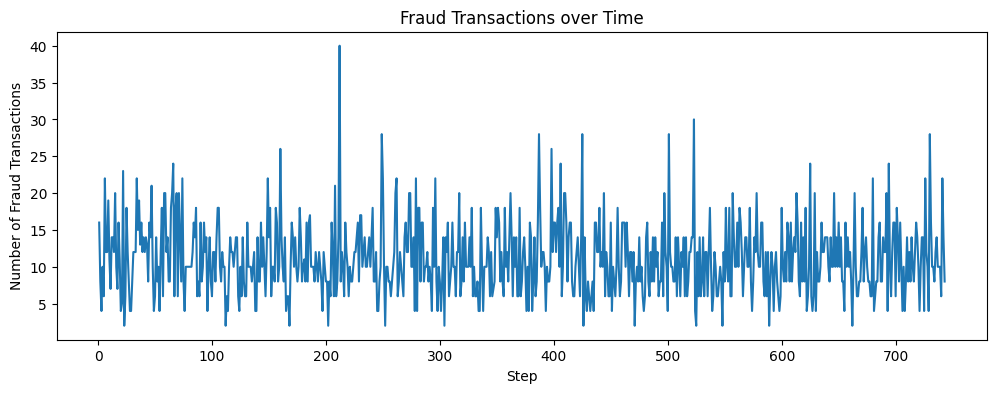

In [26]:
fraud_per_step = (
    df[df["isFraud"] == 1]
    .groupby("step")
    .size()
)

plt.figure(figsize=(12,4))
plt.plot(fraud_per_step.index, fraud_per_step.values)
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")
plt.title("Fraud Transactions over Time")
plt.show()

Let's plot 3 plots together, with same concept:

* Total transactions over time
* Fraud transactions over time
* Non-Fraud transactions over time

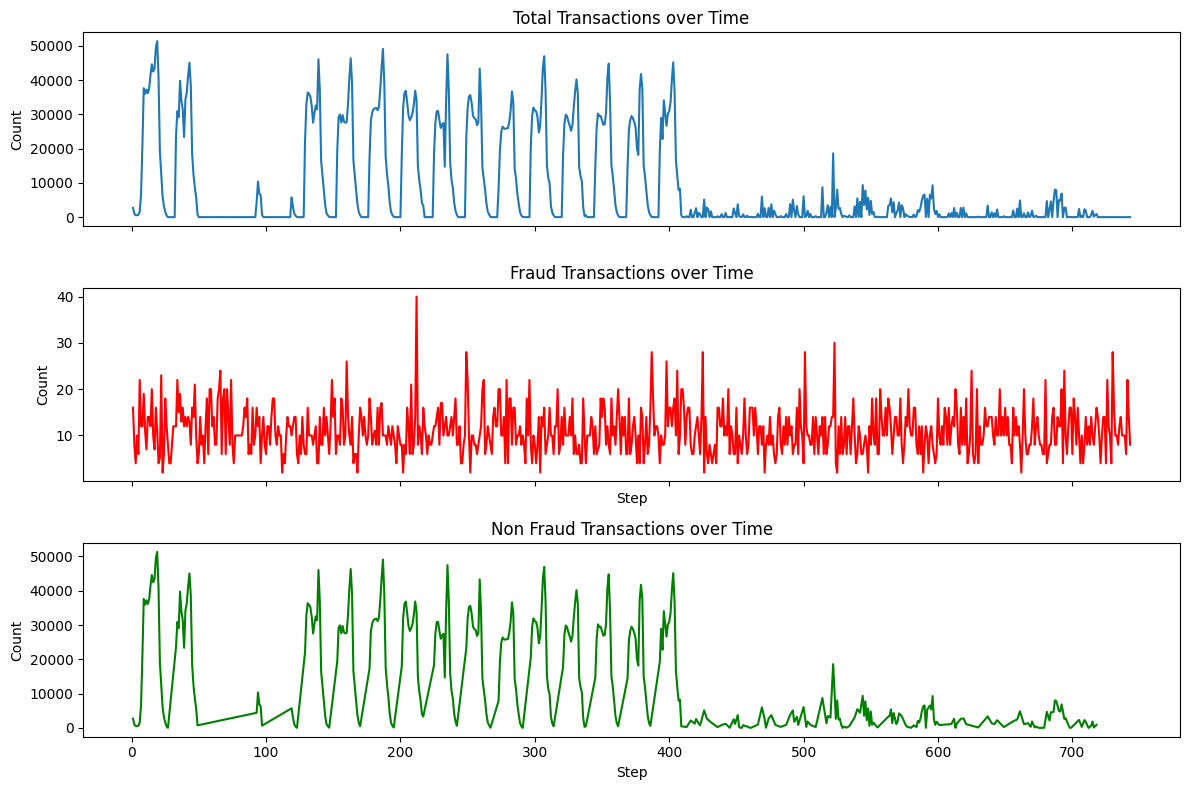

In [27]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Total transactions per step
total_per_step = df.groupby("step").size()

# Fraud transactions per step
fraud_per_step = df[df["isFraud"] == 1].groupby("step").size()

non_fraud_per_step = df[df["isFraud"] == 0].groupby("step").size()

ax[0].plot(total_per_step.index, total_per_step.values)
ax[0].set_title("Total Transactions over Time")
ax[0].set_ylabel("Count")

ax[1].plot(fraud_per_step.index, fraud_per_step.values, color="red")
ax[1].set_title("Fraud Transactions over Time")
ax[1].set_xlabel("Step")
ax[1].set_ylabel("Count")

ax[2].plot(non_fraud_per_step.index, non_fraud_per_step.values, color="green")
ax[2].set_title("Non Fraud Transactions over Time")
ax[2].set_xlabel("Step")
ax[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

> **Observation**
>
>The total number of transactions varies considerably over time, showing several recurring peaks and drops throughout the observed period. Since non-fraudulent transactions make up the majority of the dataset, their trend closely follows the overall transaction volume.
>
>In contrast, fraudulent transactions are distributed throughout the entire time period without any obvious increasing or decreasing trend. While a few isolated spikes in fraud count are observed, they do not form a consistent temporal pattern.
>
>**Possible Interpretation:**
>
>The recurring peaks in overall transaction volume may indicate periodic user activity, such as regular daily or monthly transaction patterns. However, the dataset does not provide sufficient information to confirm the exact reason for these fluctuations.
>
>Fraudulent transactions, on the other hand, appear to occur throughout the observation period rather than being concentrated within specific time intervals.

### Balance Relationships

* Sender

In [28]:
sample_df = df.sample(100000, random_state=42)

* Receiver

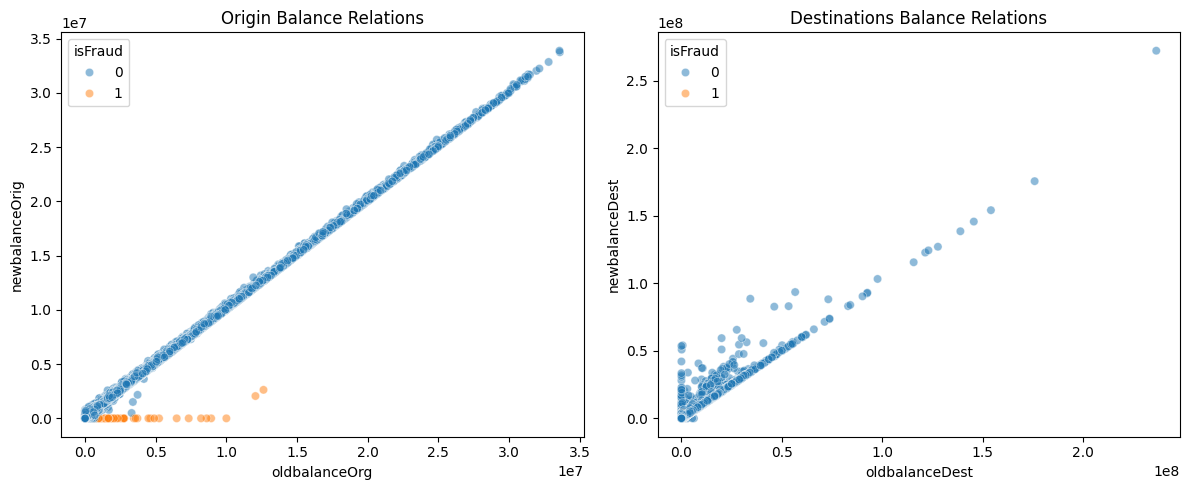

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))


sns.scatterplot(
    data=sample_df,
    x="oldbalanceOrg",
    y="newbalanceOrig",
    hue="isFraud",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Origin Balance Relations")


sns.scatterplot(
    data=sample_df,
    x="oldbalanceDest",
    y="newbalanceDest",
    hue="isFraud",
    alpha=0.5,
    ax = axes[1]
)
axes[1].set_title("Destinations Balance Relations")

plt.tight_layout()
plt.show()

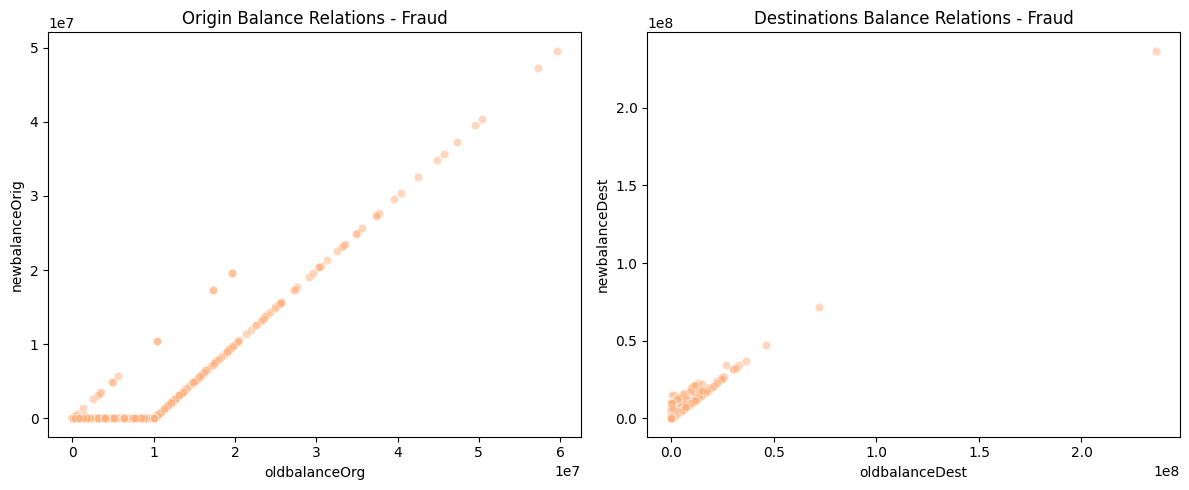

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))


sns.scatterplot(
    data=isFraud_df,
    x="oldbalanceOrg",
    y="newbalanceOrig",
    color=sns.xkcd_rgb['peach'],
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Origin Balance Relations - Fraud")


sns.scatterplot(
    data=isFraud_df,
    x="oldbalanceDest",
    y="newbalanceDest",
    color=sns.xkcd_rgb['peach'],
    alpha=0.5,
    ax = axes[1]
)
axes[1].set_title("Destinations Balance Relations - Fraud")

plt.tight_layout()
plt.show()

In [31]:
isNonFraud_df_sample = isNonFraud_df.sample(100000, random_state=42)

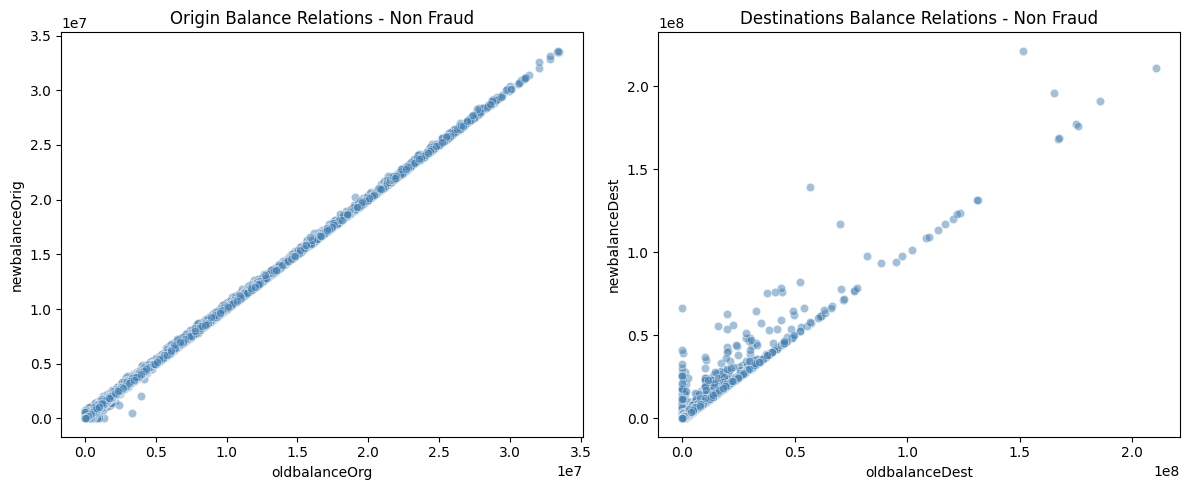

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))


sns.scatterplot(
    data=isNonFraud_df_sample,
    x="oldbalanceOrg",
    y="newbalanceOrig",
    color="steelblue",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Origin Balance Relations - Non Fraud")


sns.scatterplot(
    data=isNonFraud_df_sample,
    x="oldbalanceDest",
    y="newbalanceDest",
    color="steelblue",
    alpha=0.5,
    ax = axes[1]
)
axes[1].set_title("Destinations Balance Relations - Non Fraud")

plt.tight_layout()
plt.show()

> **Observation**
>
>Both fraudulent and non-fraudulent transactions show a strong positive relationship between the old and new account balances. This is expected, as the account balance after a transaction is naturally dependent on the balance before the transaction.
>
>The scatter plots for the two classes appear visually similar, indicating that these balance relationships alone do not clearly distinguish fraudulent transactions from legitimate ones.

### Correlation Matrix

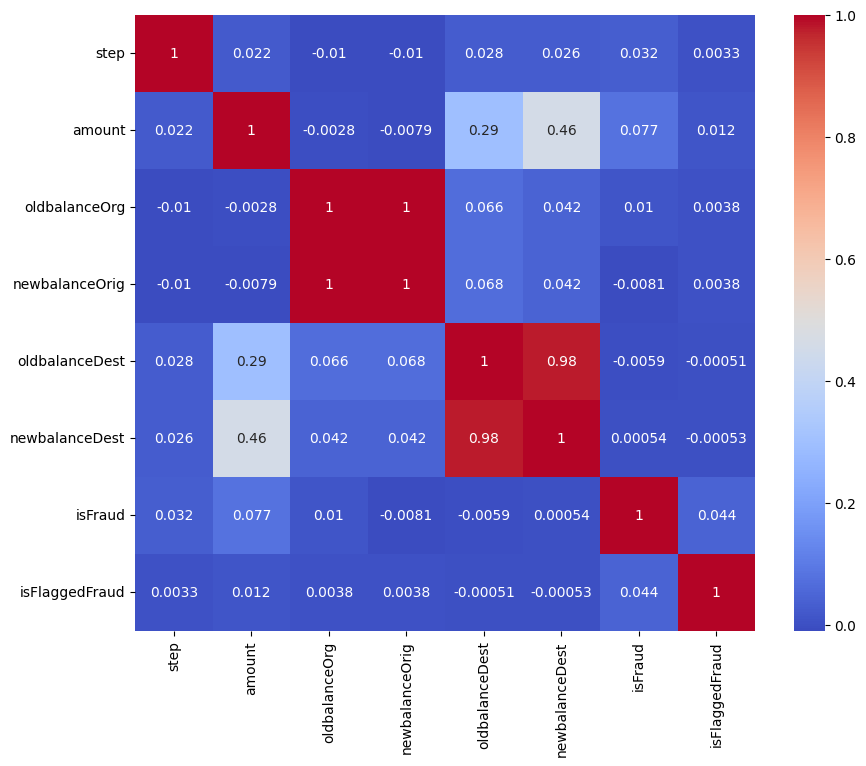

In [33]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

In [34]:
corr["isFraud"].sort_values(ascending=False)

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

* Does the built-in flag actually catch fraud?
* Does it miss most frauds?

In [35]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"]
)

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


* Does the built-in flag actually catch fraud? - No
* Does it miss most frauds? - Yes

## EDA Summary

The exploratory analysis provided several important insights into the dataset:

- The dataset is highly imbalanced, with fraudulent transactions accounting for only a small fraction of all transactions.
- Fraudulent transactions are observed only in the **TRANSFER** and **CASH_OUT** transaction types, making transaction type an important feature.
- Transaction amount is highly right-skewed, with both fraudulent and legitimate transactions containing large-value outliers. Therefore, transaction amount alone is insufficient to distinguish fraudulent behavior.
- Transaction activity follows noticeable temporal patterns, whereas fraudulent transactions are distributed throughout the observed period without a clear temporal trend.
- The raw account balance features did not provide clear visual separation between fraudulent and non-fraudulent transactions when analyzed independently.

Overall, the exploratory analysis suggests that individual features alone are not sufficient to explain fraudulent behavior. This motivates the need for **feature engineering**, where existing variables can be combined to create more informative features that better capture suspicious transaction patterns.

## Feature Engineering

### Balance Difference

During EDA, we observed that the balance columns did not always seem to follow the expected transaction logic. Therefore, we compute the expected balance and the balance error to identify transactions with inconsistent balance updates, which may indicate fraudulent behavior.

In [36]:
df["balanceDiffOrig"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
)

df["balanceDiffDest"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)

### Balance Error

Let us also add a column with the error captured with actual balance vs entered balance

In [37]:
df["origError"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["destError"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

### Fraction of Balance Transferred

The transaction amount alone does not provide much information, as it depends on the customer's account balance. Instead, we calculate the fraction of the available balance that was transferred, which better reflects the significance of the transaction relative to the sender's funds.

In [38]:
df["fraction_used"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    np.nan
)

### Remaining balance fraction

Rather than looking at the remaining balance directly, we compute the fraction of the original balance left after the transaction. Fraudulent transactions may leave unusually small remaining balances, making this feature more informative than the raw balance.

In [39]:
df["remaining_fraction"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["newbalanceOrig"] / df["oldbalanceOrg"],
    np.nan
)

### Origin account has zero balance

Transactions initiated from accounts with zero balance are unusual and may indicate inconsistencies or suspicious behavior. This binary feature explicitly captures that information instead of relying on the model to infer it.

In [40]:
df["origin_zero_balance"] = (
    df["oldbalanceOrg"] == 0
).astype(int)

### Destination account has zero balance

Similarly, destination accounts with zero initial balance may represent newly created or inactive accounts. This feature helps the model identify such potentially suspicious recipients.

In [41]:
df["destination_zero_balance"] = (
    df["oldbalanceDest"] == 0
).astype(int)

### Balance changed?

* Origin: A successful transaction should normally update the sender's account balance. This feature checks whether the origin balance changed after the transaction, allowing the model to identify unexpected balance behavior.

* Destination: Likewise, the recipient's balance is expected to change after receiving money. This feature captures whether the destination balance was updated as expected.

In [42]:
df["origin_balance_changed"] = (
    df["oldbalanceOrg"] != df["newbalanceOrig"]
).astype(int)

df["destination_balance_changed"] = (
    df["oldbalanceDest"] != df["newbalanceDest"]
).astype(int)

### Entire balance transferred?

Fraudulent transactions may attempt to transfer the entire available balance from an account. This feature identifies transactions where the transferred amount is approximately equal to the sender's original balance.

In [43]:
df["full_balance_transfer"] = np.isclose(
    df["amount"],
    df["oldbalanceOrg"],
    atol=1e-2
).astype(int)

### Transaction Fraction

Instead of considering the transaction amount in isolation, we measure its size relative to the total funds involved in the transaction. This normalizes the transaction amount across customers with different account balances.

In [44]:
df["transaction_fraction"] = np.where(
    (df["oldbalanceOrg"] + df["oldbalanceDest"]) > 0,
    df["amount"] /
    (df["oldbalanceOrg"] + df["oldbalanceDest"]),
    np.nan
)

### Cash-Transfer Indicator

During EDA, we observed that fraudulent transactions occurred only in TRANSFER and CASH_OUT transaction types. This binary feature explicitly captures that observation, making it easier for the model to leverage this pattern.

In [45]:
df["is_cash_transfer"] = (
    df["type"].isin(["TRANSFER","CASH_OUT"])
).astype(int)

## Correlation Matrix - Final

In [46]:
df.corr(numeric_only=True)["isFraud"]\
    .sort_values(ascending=False)

isFraud                        1.000000
full_balance_transfer          0.988474
balanceDiffOrig                0.362472
amount                         0.076688
destError                      0.055120
isFlaggedFraud                 0.044109
is_cash_transfer               0.040938
step                           0.031578
balanceDiffDest                0.027028
origin_balance_changed         0.024604
destination_zero_balance       0.016471
origError                      0.011283
oldbalanceOrg                  0.010154
newbalanceDest                 0.000535
transaction_fraction          -0.000557
remaining_fraction            -0.000990
fraction_used                 -0.001279
oldbalanceDest                -0.005885
newbalanceOrig                -0.008148
destination_balance_changed   -0.009959
origin_zero_balance           -0.024874
Name: isFraud, dtype: float64

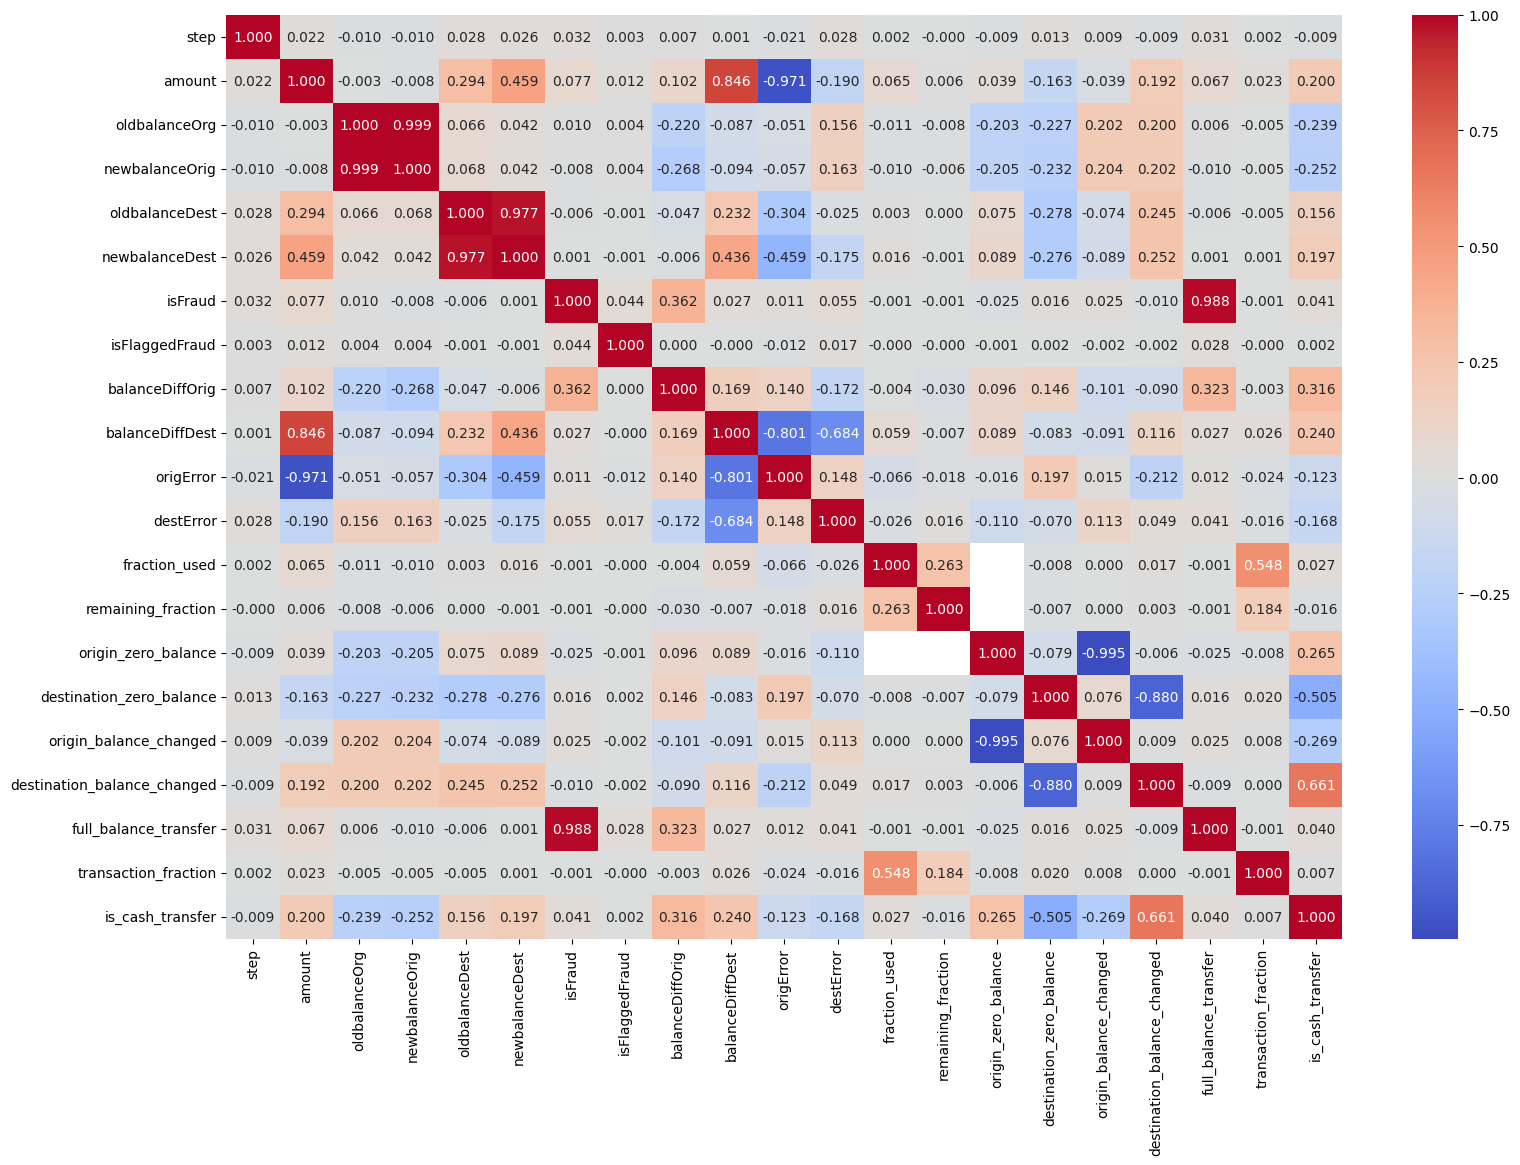

In [47]:
plt.figure(figsize=(18,12))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            fmt=".3f",
            cmap="coolwarm")

plt.show()

### Observation

The correlation matrix provides an overview of the linear relationship between the features and the target variable (`isFraud`).

- The engineered feature **`full_balance_transfer`** shows the strongest positive correlation with fraud. This suggests that transactions transferring almost the entire available balance are highly associated with fraudulent activity in this dataset.
- **`balanceDiffOrig`** also exhibits a moderate positive correlation, indicating that inconsistencies between the expected and actual origin account balances may be useful indicators of fraud.
- **`destError`**, **`amount`**, and **`is_cash_transfer`** show relatively weaker positive correlations, suggesting that they may contribute additional predictive information when combined with other features.
- Most of the remaining engineered features have correlations close to zero. This does **not** necessarily mean they are unimportant; it simply indicates that they do not have a strong **linear** relationship with the target. They may still improve model performance by interacting with other features or by capturing non-linear patterns.

Overall, the feature engineering process has introduced several informative features that are more strongly related to fraudulent transactions than the original balance variables, providing a richer representation for the machine learning models.

In [48]:
pd.crosstab(
    df["full_balance_transfer"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
full_balance_transfer,,
0,99.997183,0.002817
1,0.111899,99.888101


In [49]:
pd.crosstab(
    df["full_balance_transfer"],
    df["isFraud"]
)

isFraud,0,1
full_balance_transfer,,
0,6354398,179
1,9,8034


> **Observation**
>
>The full_balance_transfer feature shows an unusually high correlation with the target. This likely reflects the characteristics of the synthetic PaySim dataset, where fraudulent transactions often involve transferring the sender's entire available balance. Such a feature should be validated carefully before assuming it generalizes to real-world financial systems.

## Data Pre-Processing

### Handling Missing Values

The engineered features `fraction_used`, `remaining_fraction`, and `transaction_fraction` contain missing values because they involve division by the account balance, which is zero for some transactions.

Before imputing these missing values, we first investigate whether they are associated with fraudulent transactions. This helps us understand whether the missing values themselves carry useful information or simply arise from valid transaction scenarios.

In [50]:
df.isna().sum()

step                                 0
type                                 0
amount                               0
nameOrig                             0
oldbalanceOrg                        0
newbalanceOrig                       0
nameDest                             0
oldbalanceDest                       0
newbalanceDest                       0
isFraud                              0
isFlaggedFraud                       0
balanceDiffOrig                      0
balanceDiffDest                      0
origError                            0
destError                            0
fraction_used                  2102449
remaining_fraction             2102449
origin_zero_balance                  0
destination_zero_balance             0
origin_balance_changed               0
destination_balance_changed          0
full_balance_transfer                0
transaction_fraction            776105
is_cash_transfer                     0
dtype: int64

In [51]:
df[df["fraction_used"].isna()].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,destError,fraction_used,remaining_fraction,origin_zero_balance,destination_zero_balance,origin_balance_changed,destination_balance_changed,full_balance_transfer,transaction_fraction,is_cash_transfer
29,1,PAYMENT,9920.52,C764826684,0.0,0.0,M1940055334,0.0,0.0,0,...,9920.52,NaN,NaN,1,1,0,0,0,NaN,0
30,1,PAYMENT,3448.92,C2103763750,0.0,0.0,M335107734,0.0,0.0,0,...,3448.92,NaN,NaN,1,1,0,0,0,NaN,0
31,1,PAYMENT,4206.84,C215078753,0.0,0.0,M1757317128,0.0,0.0,0,...,4206.84,NaN,NaN,1,1,0,0,0,NaN,0
32,1,PAYMENT,5885.56,C840514538,0.0,0.0,M1804441305,0.0,0.0,0,...,5885.56,NaN,NaN,1,1,0,0,0,NaN,0
33,1,PAYMENT,5307.88,C1768242710,0.0,0.0,M1971783162,0.0,0.0,0,...,5307.88,NaN,NaN,1,1,0,0,0,NaN,0


In [52]:
df[df["fraction_used"].isna()]["isFraud"].value_counts()

isFraud
0    2102408
1         41
Name: count, dtype: int64

>Since the vast majority of these missing values belong to non-fraudulent transactions, they do not appear to indicate fraudulent behavior on their own. Therefore, they can be safely imputed for model training.

### Imputing Undefined Ratios

The engineered features `fraction_used`, `remaining_fraction`, and `transaction_fraction` contain missing values when the denominator (account balance) is zero, making the ratio mathematically undefined.

Instead of replacing these values with `0`, they are imputed with `-1`.

This decision is made because:

- A value of **0** has a valid meaning (e.g., 0% of the balance was transferred), whereas these missing values do **not** represent a zero ratio—they represent an **undefined ratio**.
- Using **-1** preserves this distinction and allows the model to recognize these cases as a separate category instead of confusing them with genuine zero-valued ratios.
- Although some tree-based models can handle missing values directly, using a consistent numerical representation (`-1`) ensures compatibility across different machine learning models while retaining the information that the ratio could not be computed.

In [53]:
df["fraction_used"] = df["fraction_used"].fillna(-1)
df["remaining_fraction"] = df["remaining_fraction"].fillna(-1)
df["transaction_fraction"] = df["transaction_fraction"].fillna(-1)

In [54]:
df.isna().sum()

step                           0
type                           0
amount                         0
nameOrig                       0
oldbalanceOrg                  0
newbalanceOrig                 0
nameDest                       0
oldbalanceDest                 0
newbalanceDest                 0
isFraud                        0
isFlaggedFraud                 0
balanceDiffOrig                0
balanceDiffDest                0
origError                      0
destError                      0
fraction_used                  0
remaining_fraction             0
origin_zero_balance            0
destination_zero_balance       0
origin_balance_changed         0
destination_balance_changed    0
full_balance_transfer          0
transaction_fraction           0
is_cash_transfer               0
dtype: int64

### Drop Unnecessary Columns

Customer IDs (`nameOrig` and `nameDest`) are unique identifiers and do not carry meaningful information for predicting fraud, so they are removed to avoid introducing unnecessary noise into the model.

Even if few times it may seem, some frauds are connected to users or identifiers, but in future there might me new identifiers, and that would add no real value to train model on something that would change in future.

In [55]:
df = df.drop(columns=["nameOrig", "nameDest"])

### Encode Transaction Type

Since `type` is a categorical feature with no natural ordering, One-Hot Encoding is used to represent each transaction type as an independent binary feature.

In [56]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=False,
    dtype=int
)

# Model Training

### Separate Features and Target

Before training, the target variable is separated from the input features so that the model learns to predict fraud using only the available transaction attributes.

In [57]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

### Stratified Train-Test Split

Since the dataset is highly imbalanced, a stratified split preserves the same fraud-to-non-fraud ratio in both the training and testing sets, resulting in a fair and reliable evaluation.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


### Feature Scaling (Only for Logistic Regression)

Logistic Regression is distance- and gradient-based, so numerical features are standardized to ensure that features with larger scales do not dominate the optimization process.

In [60]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

## Baseline Models

The objective of this phase is to establish baseline machine learning models for fraud detection.

Multiple algorithms are trained and evaluated using the same train-test split to understand their strengths and weaknesses on this highly imbalanced dataset.

Since accuracy can be misleading for imbalanced classification problems, the models will primarily be evaluated using Precision, Recall, F1-score, ROC-AUC and the Confusion Matrix.

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Logistic Regression

Logistic Regression is used as a simple linear baseline model. Since it is sensitive to feature scales, the standardized dataset is used for training.

### Training

In [63]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Prediction

In [64]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

### Evaluation

In [65]:
print(classification_report(y_test, y_pred_lr))

print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall   :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.88      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.94      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9998286869245688
Precision: 0.8840970350404312
Recall   : 0.9981740718198417
F1 Score : 0.9376786735277302
ROC AUC  : 0.9998807269426117


### Confusion Matrix

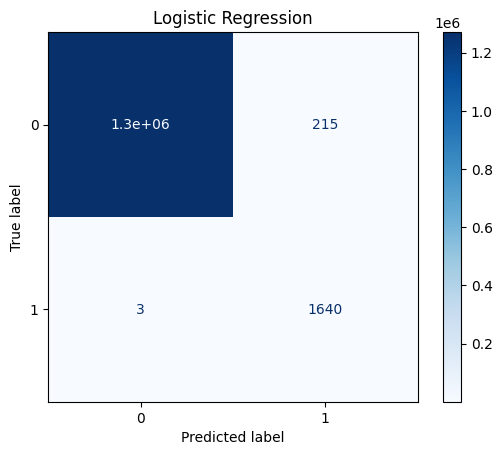

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

### Store Results

In [67]:
results = []

results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy_score(y_test,y_pred_lr),
    "Precision":precision_score(y_test,y_pred_lr),
    "Recall":recall_score(y_test,y_pred_lr),
    "F1":f1_score(y_test,y_pred_lr),
    "ROC_AUC":roc_auc_score(y_test,y_prob_lr)
})

## Random Forest

Random Forest is a tree-based ensemble model that can capture complex non-linear relationships and is generally robust to feature scaling.

### Training

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Prediction

In [69]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

### Evaluation

In [70]:
print(classification_report(y_test, y_pred_rf))

print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall   :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9999968566408177
Precision: 1.0
Recall   : 0.9975654290931223
F1 Score : 0.9987812309567337
ROC AUC  : 0.9990867133613295


### Confusion Matrix

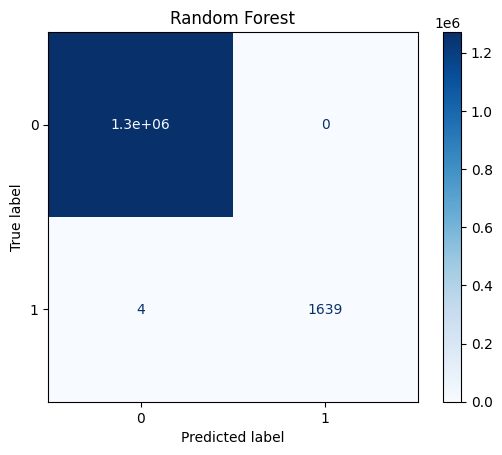

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest")
plt.show()

### Store Results

In [72]:
results.append({
    "Model":"Random Forest Baseline",
    "Accuracy":accuracy_score(y_test,y_pred_rf),
    "Precision":precision_score(y_test,y_pred_rf),
    "Recall":recall_score(y_test,y_pred_rf),
    "F1":f1_score(y_test,y_pred_rf),
    "ROC_AUC":roc_auc_score(y_test,y_prob_rf)
})

## XGBoost

XGBoost is a gradient boosting algorithm that often performs exceptionally well on structured tabular datasets and can naturally model complex feature interactions.

### Training

In [73]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1]
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Prediction

In [74]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [13:01:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### Evaluation

In [75]:
print(classification_report(y_test, y_pred_xgb))

print("Accuracy :", accuracy_score(y_test,y_pred_xgb))
print("Precision:", precision_score(y_test,y_pred_xgb))
print("Recall   :", recall_score(y_test,y_pred_xgb))
print("F1 Score :", f1_score(y_test,y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test,y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.42      1.00      0.59      1643

    accuracy                           1.00   1272524
   macro avg       0.71      1.00      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9982444338967281
Precision: 0.4235446313065977
Recall   : 0.9963481436396835
F1 Score : 0.59440813362382
ROC AUC  : 0.9973127200540772


### Confusion Matrix

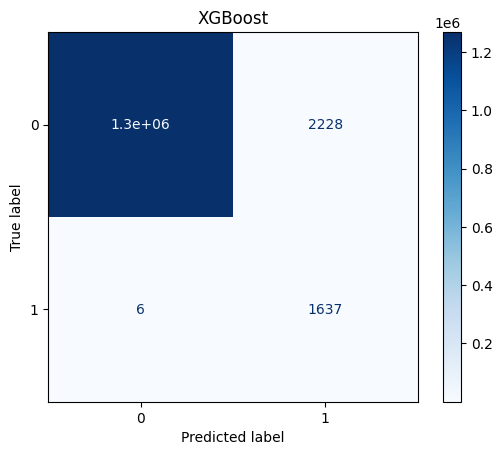

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("XGBoost")
plt.show()

### Store Results

In [77]:
results.append({
    "Model":"XGBoost Baseline",
    "Accuracy":accuracy_score(y_test,y_pred_xgb),
    "Precision":precision_score(y_test,y_pred_xgb),
    "Recall":recall_score(y_test,y_pred_xgb),
    "F1":f1_score(y_test,y_pred_xgb),
    "ROC_AUC":roc_auc_score(y_test,y_prob_xgb)
})

## Baseline Model Comparison

The three baseline models were evaluated using multiple metrics suitable for imbalanced classification.

Rather than relying solely on accuracy, greater emphasis is placed on Precision, Recall, F1-score and ROC-AUC, as these metrics better reflect the model's ability to identify fraudulent transactions while minimizing false predictions.

The comparison table below summarizes the overall performance of each baseline model.

In [78]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest Baseline,0.999997,1.000000,0.997565,0.998781,0.999087
0,Logistic Regression,0.999829,0.884097,0.998174,0.937679,0.999881
2,XGBoost Baseline,0.998244,0.423545,0.996348,0.594408,0.997313


In [79]:
results_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.999829,0.884097,0.998174,0.937679,0.999881
1,Random Forest Baseline,0.999997,1.000000,0.997565,0.998781,0.999087
2,XGBoost Baseline,0.998244,0.423545,0.996348,0.594408,0.997313


### Baseline Model Comparison

The three baseline models demonstrate that the engineered features are highly informative for fraud detection.

- **Random Forest** achieved the best overall performance, obtaining the highest F1-score and nearly perfect Precision and Recall. This indicates that the model effectively distinguishes fraudulent and legitimate transactions on this dataset.

- **Logistic Regression** also performed remarkably well despite being a linear model. The strong performance suggests that the engineered features provide good separation between the two classes.

- **XGBoost** achieved very high Recall but considerably lower Precision. This indicates that while the model successfully identifies most fraudulent transactions, it also generates a larger number of false positives. This behavior is likely influenced by the class imbalance handling strategy (`scale_pos_weight`), which prioritizes detecting fraudulent transactions.

Overall, the results suggest that the feature engineering process substantially improved the predictive power of the dataset, with Random Forest emerging as the strongest baseline model.

# Experimentations

## Handling Class Imbalance

The dataset contains only about 0.12% fraudulent transactions, making it highly imbalanced.

Rather than balancing the dataset through oversampling, different model-specific imbalance handling strategies are explored.

- Logistic Regression and Random Forest use `class_weight="balanced"`.
- XGBoost uses `scale_pos_weight`, which assigns greater importance to the minority fraud class during training.

This approach preserves the original data distribution while reducing the model's bias toward the majority class.

## Experiment: Effect of `scale_pos_weight` in XGBoost

Since XGBoost produced a noticeably different balance between Precision and Recall compared to the other models, an additional experiment is performed by varying the `scale_pos_weight` parameter.

The objective is to observe how changing the penalty assigned to the minority class affects the model's ability to detect fraudulent transactions and the trade-off between Precision and Recall.

In [80]:
weights = [
    1,
    100,
    300,
    500,
    y_train.value_counts()[0] / y_train.value_counts()[1]
]

In [81]:
from xgboost import XGBClassifier

xgb_results = []

for w in weights:
    xgb = XGBClassifier(
        tree_method="hist",
        device="cuda",
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=w
    )

    xgb.fit(X_train,y_train)

    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:,1]

    xgb_results.append({
        "Model":f"XGBoost_weights_{int(w)}",
        "Accuracy":accuracy_score(y_test,y_pred_xgb),
        "Precision":precision_score(y_test,y_pred_xgb),
        "Recall":recall_score(y_test,y_pred_xgb),
        "F1":f1_score(y_test,y_pred_xgb),
        "ROC_AUC":roc_auc_score(y_test,y_prob_xgb)
    })

    print(f"XGBoost_weights_{int(w)} Completed")

XGBoost_weights_1 Completed
XGBoost_weights_100 Completed
XGBoost_weights_300 Completed
XGBoost_weights_500 Completed
XGBoost_weights_773 Completed


In [82]:
xgb_results_df = pd.DataFrame(xgb_results)

xgb_results_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost_weights_1,0.999995,0.998781,0.997565,0.998173,0.999431
1,XGBoost_weights_100,0.999993,0.996959,0.997565,0.997262,0.999416
2,XGBoost_weights_300,0.999788,0.862269,0.994522,0.923686,0.997946
3,XGBoost_weights_500,0.999992,0.996353,0.997565,0.996959,0.999768
4,XGBoost_weights_773,0.998244,0.423545,0.996348,0.594408,0.997313


>**Observation**
>
>The effect of `scale_pos_weight` was evaluated to understand how increasing the importance of the minority (fraud) class influences model performance.
>
> - Increasing the weight generally encouraged the model to predict the fraud class more aggressively.
> - However, assigning an excessively large weight (`773`) significantly reduced Precision by increasing the number of false positive predictions, even though Recall remained high.
> - Surprisingly, a weight of **1** (no additional class weighting) achieved the best overall F1-score on this dataset.
> - This suggests that the engineered features already provide strong discrimination between fraudulent and legitimate transactions, reducing the need for aggressive class weighting.
>
>This experiment highlights the importance of tuning `scale_pos_weight` rather than relying solely on the default recommendation based on the class imbalance ratio.

## Random Forest Hyperparameter Experiments

Although the baseline Random Forest model already achieved excellent performance, hyperparameter tuning is still performed to better understand how different model configurations affect performance.

The objective of these experiments is not necessarily to obtain a higher score, but to study the influence of key hyperparameters on the model's complexity, generalization ability, and computational cost. Such experiments help identify whether the baseline model is already close to optimal or if further improvements are possible.

### Experiment 1 - Number of Estimators

In [83]:
# number of tress
n_estimators = [50, 100, 200, 300]

In [84]:
rf_results = []

for est in n_estimators:
    rf = RandomForestClassifier(
        n_estimators=est,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
    
    rf.fit(X_train,y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:,1]

    rf_results.append({
        "Model":f"Random Forest_Est:_{est}",
        "Accuracy":accuracy_score(y_test,y_pred_rf),
        "Precision":precision_score(y_test,y_pred_rf),
        "Recall":recall_score(y_test,y_pred_rf),
        "F1":f1_score(y_test,y_pred_rf),
        "ROC_AUC":roc_auc_score(y_test,y_prob_rf)
    })

    print(f"Random Forest_Est:_{est} training completed")

Random Forest_Est:_50 training completed
Random Forest_Est:_100 training completed
Random Forest_Est:_200 training completed
Random Forest_Est:_300 training completed


In [85]:
rf_results_df = pd.DataFrame(rf_results)

rf_results_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest_Est:_50,0.999997,1.000000,0.997565,0.998781,0.999087
1,Random Forest_Est:_100,0.999997,1.000000,0.997565,0.998781,0.999087
2,Random Forest_Est:_200,0.999997,1.000000,0.997565,0.998781,0.999087
3,Random Forest_Est:_300,0.999997,1.000000,0.997565,0.998781,0.999087


> **Observation**
>
>The effect of varying the number of trees (`n_estimators`) was evaluated to determine whether increasing the ensemble size improves the model's performance.
>
>The results show that all evaluated configurations (50, 100, 200, and 300 trees) produced identical performance across all evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC.
>
>This indicates that the Random Forest model converges with as few as **50 trees** on this dataset. Increasing the number of trees beyond this point does not provide any measurable performance improvement, while it increases the computational cost and training time.
>
>Therefore, using **50 estimators** provides the best trade-off between model performance and computational efficiency for this dataset.

### Experiment 2 - Max Depth

In [86]:
# Maximum Depth
max_depth = [10, 20, 30, None]

In [87]:
rf_results_depth = []

for depth in max_depth:
    rf = RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth = depth
    )
    
    rf.fit(X_train,y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:,1]

    rf_results_depth.append({
        "Model":f"Random Forest_Depth:_{depth}",
        "Accuracy":accuracy_score(y_test,y_pred_rf),
        "Precision":precision_score(y_test,y_pred_rf),
        "Recall":recall_score(y_test,y_pred_rf),
        "F1":f1_score(y_test,y_pred_rf),
        "ROC_AUC":roc_auc_score(y_test,y_prob_rf)
    })

    print(f"Random Forest_Depth:_{depth} training completed")

Random Forest_Depth:_10 training completed
Random Forest_Depth:_20 training completed
Random Forest_Depth:_30 training completed
Random Forest_Depth:_None training completed


In [88]:
rf_results_depth_df = pd.DataFrame(rf_results_depth)

rf_results_depth_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest_Depth:_10,0.999963,0.974435,0.997565,0.985865,0.999958
1,Random Forest_Depth:_20,0.999997,1.000000,0.997565,0.998781,0.999086
2,Random Forest_Depth:_30,0.999997,1.000000,0.997565,0.998781,0.999087
3,Random Forest_Depth:_None,0.999997,1.000000,0.997565,0.998781,0.999087


>**Observation**
>
>The maximum depth of the Random Forest was varied to study the effect of tree complexity on model performance.
>
>A depth of **10** resulted in a slight decrease in Precision and F1-score, suggesting that the trees were not sufficiently complex to capture all fraud-related patterns.
>
>Increasing the maximum depth to **20** significantly improved the performance. Further increasing the depth to **30** or allowing unlimited growth (`None`) did not produce any additional improvement.
>
>This indicates that a maximum depth of **20** is sufficient for the model to learn the underlying patterns in the dataset. Since deeper trees provide no measurable performance gain while increasing model complexity, **`max_depth = 20`** is selected as the preferred configuration.

### Experiment 3 - Minimum Sample Leaves

In [89]:
# Minimum samples leaf
min_samples_leaf = [1, 2, 5]

In [90]:
rf_results_leaves = []

for leaves in min_samples_leaf:
    rf = RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
        max_depth = 20,
        min_samples_leaf = leaves
    )
    
    rf.fit(X_train,y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:,1]

    rf_results_leaves.append({
        "Model":f"Random Forest_Leaves:_{leaves}",
        "Accuracy":accuracy_score(y_test,y_pred_rf),
        "Precision":precision_score(y_test,y_pred_rf),
        "Recall":recall_score(y_test,y_pred_rf),
        "F1":f1_score(y_test,y_pred_rf),
        "ROC_AUC":roc_auc_score(y_test,y_prob_rf)
    })

    print(f"Random Forest_Leaves:_{leaves} training completed")

Random Forest_Leaves:_1 training completed
Random Forest_Leaves:_2 training completed
Random Forest_Leaves:_5 training completed


In [91]:
rf_results_leaves_df = pd.DataFrame(rf_results_leaves)

rf_results_leaves_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest_Leaves:_1,0.999997,1.000000,0.997565,0.998781,0.999086
1,Random Forest_Leaves:_2,0.999997,1.000000,0.997565,0.998781,0.999389
2,Random Forest_Leaves:_5,0.999996,0.999390,0.997565,0.998477,0.999583


>**Observation**
>
>The `min_samples_leaf` parameter was varied to study how restricting the minimum number of samples in each leaf node affects the Random Forest model.
>
> - Setting `min_samples_leaf` to **1** and **2** produced identical Accuracy, Precision, Recall, and F1-score, indicating that a slight increase in the minimum leaf size does not negatively affect the model.
> - Increasing the value to **5** resulted in a small decrease in Precision and F1-score. This suggests that forcing each leaf to contain more samples makes the model slightly less capable of capturing subtle fraud patterns.
> - Although `min_samples_leaf = 5` achieved a marginally higher ROC-AUC, the difference is very small and comes at the cost of reduced Precision.
>
>Overall, **`min_samples_leaf = 2`** provides a good balance between model simplicity and predictive performance, and is selected as the final configuration.

## Final Set of Models

Using the best models trained so far with the hyper parameter tuning experiments

### Optimized Random Forest Model

In [92]:
rf_optim = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
    max_depth = 20,
    min_samples_leaf = 2
)

rf_optim.fit(X_train,y_train)

y_pred_rf_optim = rf_optim.predict(X_test)
y_prob_rf_optim = rf_optim.predict_proba(X_test)[:,1]

results.append({
    "Model":f"Random Forest Optimized",
    "Accuracy":accuracy_score(y_test,y_pred_rf_optim),
    "Precision":precision_score(y_test,y_pred_rf_optim),
    "Recall":recall_score(y_test,y_pred_rf_optim),
    "F1":f1_score(y_test,y_pred_rf_optim),
    "ROC_AUC":roc_auc_score(y_test,y_prob_rf_optim)
})

### Optimized XGBoost Model

In [93]:
xgb_optim = XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=1
)

xgb_optim.fit(X_train,y_train)

y_pred_xgb_optim = xgb_optim.predict(X_test)
y_prob_xgb_optim = xgb_optim.predict_proba(X_test)[:,1]

results.append({
    "Model":f"XGBoost Optimized",
    "Accuracy":accuracy_score(y_test,y_pred_xgb_optim),
    "Precision":precision_score(y_test,y_pred_xgb_optim),
    "Recall":recall_score(y_test,y_pred_xgb_optim),
    "F1":f1_score(y_test,y_pred_xgb_optim),
    "ROC_AUC":roc_auc_score(y_test,y_prob_xgb_optim)
})

y_pred_xgb_optim = xgb_optim.predict(X_test)
y_prob_xgb_optim = xgb_optim.predict_proba(X_test)[:,1]

results.append({
    "Model":f"XGBoost Optimized",
    "Accuracy":accuracy_score(y_test,y_pred_xgb_optim),
    "Precision":precision_score(y_test,y_pred_xgb_optim),
    "Recall":recall_score(y_test,y_pred_xgb_optim),
    "F1":f1_score(y_test,y_pred_xgb_optim),
    "ROC_AUC":roc_auc_score(y_test,y_prob_xgb_optim)
})

In [94]:
results_df = pd.DataFrame(results)

results_df.style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.999829,0.884097,0.998174,0.937679,0.999881
1,Random Forest Baseline,0.999997,1.000000,0.997565,0.998781,0.999087
2,XGBoost Baseline,0.998244,0.423545,0.996348,0.594408,0.997313
3,Random Forest Optimized,0.999997,1.000000,0.997565,0.998781,0.999389
4,XGBoost Optimized,0.999995,0.998781,0.997565,0.998173,0.999431
5,XGBoost Optimized,0.999995,0.998781,0.997565,0.998173,0.999431


### Observation

The optimized models were compared with their respective baseline versions to evaluate the impact of targeted hyperparameter tuning.

- **Random Forest** showed a slight improvement in ROC-AUC after optimization while maintaining perfect Precision and the same Recall and F1-score. This indicates that the tuned model achieves similar predictive performance with a more efficient and controlled model configuration.

- **XGBoost** showed a remarkable improvement after tuning `scale_pos_weight`. Compared to the baseline model, Precision increased significantly while maintaining high Recall, resulting in a much higher F1-score. This demonstrates that selecting an appropriate class weight is crucial for highly imbalanced datasets.

Overall, the **Optimized Random Forest** achieved the best overall performance and is selected as the final model for this project.

>Although oversampling techniques such as SMOTE are commonly used for imbalanced datasets, they were not applied in this project. Since the dataset already contains thousands of fraud examples and the tree-based models support class weighting, model-specific imbalance handling was preferred to preserve the original transaction distribution.

# Feature Importance

Although the evaluation metrics indicate that the model performs extremely well, it is equally important to understand *why* the model makes its predictions.

Random Forest provides feature importance scores based on how much each feature contributes to reducing impurity across all decision trees. This helps identify which original and engineered features are most influential in detecting fraudulent transactions.

In [95]:
feature_importance = pd.Series(
    rf_optim.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

full_balance_transfer          2.845150e-01
origError                      2.321808e-01
balanceDiffOrig                1.121352e-01
fraction_used                  7.976308e-02
is_cash_transfer               6.656711e-02
oldbalanceOrg                  6.304277e-02
remaining_fraction             5.315566e-02
newbalanceOrig                 2.636393e-02
transaction_fraction           2.541701e-02
amount                         1.337063e-02
origin_zero_balance            7.855577e-03
destError                      7.358445e-03
balanceDiffDest                5.105109e-03
type_CASH_IN                   4.515137e-03
type_TRANSFER                  4.143877e-03
destination_zero_balance       3.396235e-03
destination_balance_changed    3.304374e-03
type_PAYMENT                   2.026211e-03
step                           1.772572e-03
oldbalanceDest                 1.687280e-03
newbalanceDest                 1.441289e-03
isFlaggedFraud                 5.160479e-04
origin_balance_changed         2

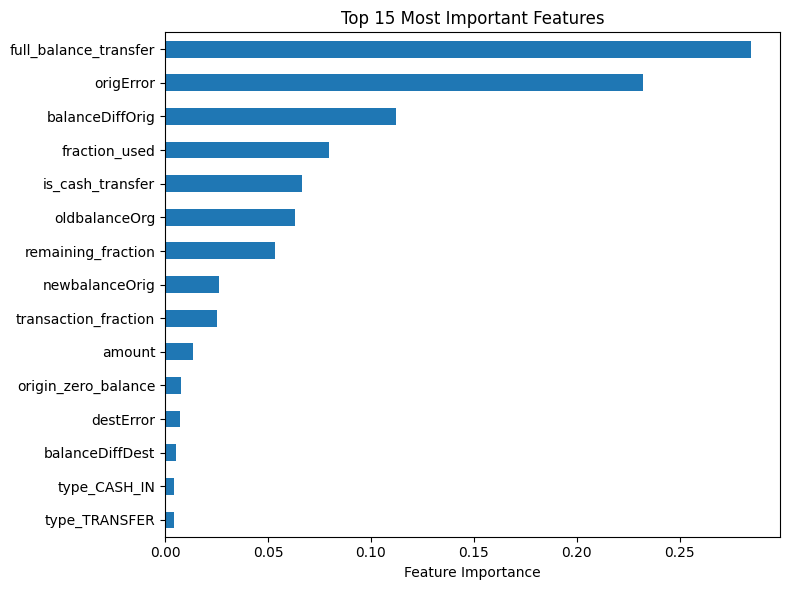

In [96]:
plt.figure(figsize=(8,6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Most Important Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

## Observation

The feature importance analysis highlights that the engineered features contribute significantly more than most of the original transaction attributes.

- `full_balance_transfer` is the most influential feature, indicating that transactions where the transferred amount is nearly equal to the sender's entire account balance are highly indicative of fraudulent activity.
- `origError` and `balanceDiffOrig` are also among the top contributors, confirming that inconsistencies between the expected and observed sender balances provide strong signals for fraud detection.
- Features such as `fraction_used`, `remaining_fraction`, and `transaction_fraction` further demonstrate that the proportion of the account balance involved in a transaction is more informative than the transaction amount alone.
- The original feature `amount` has relatively low importance compared to the engineered features, supporting the earlier EDA observation that transaction amount alone cannot reliably distinguish fraudulent and legitimate transactions.
- Transaction type features (`TRANSFER` and `CASH_OUT`) still contribute to the prediction, but their influence is considerably lower than the engineered balance-related features.

Overall, the feature importance analysis validates the feature engineering process, showing that deriving meaningful balance-based features from domain knowledge substantially improves the model's ability to detect fraudulent transactions.

# Conclusion

## Project Summary

The objective of this project was to build an effective machine learning model for detecting fraudulent online payment transactions from a highly imbalanced dataset.

The project followed a complete machine learning workflow, including:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Baseline Model Training
- Hyperparameter Optimization
- Model Evaluation
- Feature Importance Analysis

Instead of relying solely on model training, emphasis was placed on understanding the data and engineering meaningful features that capture suspicious transaction behavior.

## Key Findings

Throughout the analysis, several important observations were made:

- The dataset is extremely imbalanced, with fraudulent transactions representing only a very small fraction of all transactions.
- Fraudulent transactions primarily occur in **TRANSFER** and **CASH_OUT** transaction types.
- Transaction amount alone is not sufficient to distinguish fraudulent and legitimate transactions.
- Balance inconsistencies provide strong indicators of fraudulent activity.
- Domain-driven feature engineering significantly improved the predictive power of the dataset.
- Random Forest consistently achieved the best overall performance among all evaluated models.

## Final Model

The final selected model is an **Optimized Random Forest** with the following configuration:

- n_estimators = 50
- max_depth = 20
- min_samples_leaf = 2
- class_weight = "balanced"

This configuration provides an excellent balance between model complexity, computational efficiency, and predictive performance while achieving outstanding Precision, Recall, F1-score, and ROC-AUC.

## What I Learned

This project reinforced the importance of understanding the data before focusing on model selection.

Initially, the original transaction attributes alone provided limited insight into fraudulent behavior. Through exploratory data analysis, suspicious balance relationships were identified, leading to the creation of several engineered features such as balance differences, transaction fractions, and balance consistency checks.

Feature importance analysis later confirmed that these engineered features contributed more to the model than most of the original attributes, demonstrating how domain knowledge and feature engineering can have a greater impact than simply choosing more complex models.

## Limitations

Although the model achieved excellent performance, several limitations should be considered:

- The dataset is synthetically generated and may not capture every pattern observed in real-world financial transactions.
- Customer identifiers were excluded because they represent unique IDs and cannot generalize to unseen users.
- The model predicts fraud using individual transactions and does not utilize historical customer behavior or sequential transaction patterns.

## Future Work

This project can be further improved by:

- Incorporating customer transaction history for sequence-based fraud detection.
- Applying explainability techniques such as SHAP values to interpret individual predictions.
- Exploring anomaly detection methods alongside supervised learning.
- Building a real-time fraud detection API using FastAPI.
- Containerizing the application with Docker.
- Developing a web interface for live transaction prediction and deploying the complete system to the cloud.